Use the file data.csv which contains 169 rows and 4 columns.  
1. Convert this file into pandas Data Frame and Display basic statistics like mean, std, quartiles, etc. for this data frame.  
2. Print first and last 5 rows. Also print the shape of the dataframe. 
3. Create a correlation table for the data frame and comment about what kind of correlation is there between Duration and Calories?  
4. Find whether there any null or NA values, drop all such rows if found in the data frame and print the shape of the data frame after dropping.  
5. Prepare a scatter matrix for the following data frame. 
6. Prepare a parallel coordinates for Duration v/s Pulse, Maxpulse and Calories (all 3 other columns). 
7. Prepare a cross-tabulation for Duration v/s Pulse. 
8. Do Maxpulse have any outliers? Find using function. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('data.csv')
print(df)

     Duration  Pulse  Maxpulse  Calories
0          60    110       130     409.1
1          60    117       145     479.0
2          60    103       135     340.0
3          45    109       175     282.4
4          45    117       148     406.0
..        ...    ...       ...       ...
164        60    105       140     290.8
165        60    110       145     300.0
166        60    115       145     310.2
167        75    120       150     320.4
168        75    125       150     330.4

[169 rows x 4 columns]


In [4]:
print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nShape of DataFrame:")
print(df.shape)


First 5 Rows:
   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0

Last 5 Rows:
     Duration  Pulse  Maxpulse  Calories
164        60    105       140     290.8
165        60    110       145     300.0
166        60    115       145     310.2
167        75    120       150     320.4
168        75    125       150     330.4

Shape of DataFrame:
(169, 4)


In [5]:
print("\nCorrelation Matrix:")
corr = df.corr(numeric_only=True)
print(corr)

print("\nCorrelation between Duration and Calories:")
print(corr.loc["Duration", "Calories"])

# Comment
if corr.loc["Duration", "Calories"] > 0.7:
    print("Strong Positive Correlation")
elif corr.loc["Duration", "Calories"] > 0.3:
    print("Moderate Positive Correlation")
elif corr.loc["Duration", "Calories"] > 0:
    print("Weak Positive Correlation")
elif corr.loc["Duration", "Calories"] < -0.7:
    print("Strong Negative Correlation")
elif corr.loc["Duration", "Calories"] < -0.3:
    print("Moderate Negative Correlation")
else:
    print("Weak or No Correlation")


Correlation Matrix:
          Duration     Pulse  Maxpulse  Calories
Duration  1.000000 -0.155408  0.009403  0.922717
Pulse    -0.155408  1.000000  0.786535  0.025121
Maxpulse  0.009403  0.786535  1.000000  0.203813
Calories  0.922717  0.025121  0.203813  1.000000

Correlation between Duration and Calories:
0.9227166783472459
Strong Positive Correlation


In [ ]:
print(df.isna().sum())
df=df.dropna()
print(df.shape)


Duration    0
Pulse       0
Maxpulse    0
Calories    5
dtype: int64
(164, 4)


In [21]:
import plotly.express as px
px.scatter_matrix(df)

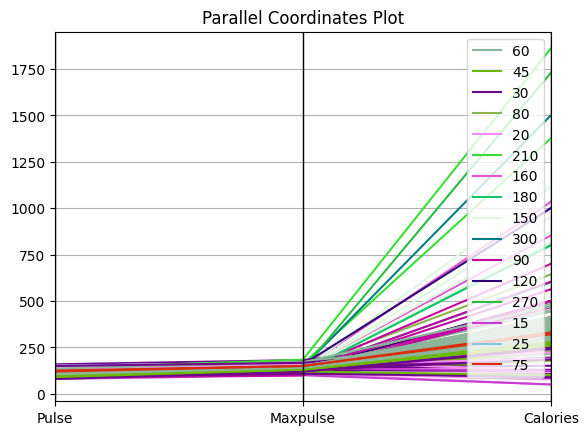

In [24]:
df_parallel = df.copy()
df_parallel["Duration_Class"] = df_parallel["Duration"].astype(str)

pd.plotting.parallel_coordinates(
    df_parallel[["Duration_Class", "Pulse", "Maxpulse", "Calories"]],
    class_column="Duration_Class"
)

plt.title("Parallel Coordinates Plot")
plt.show()


In [27]:
print("\nCross Tabulation (Duration vs Pulse):")
print(pd.crosstab(df["Duration"], df["Pulse"]))


Cross Tabulation (Duration vs Pulse):
Pulse     80   83   85   90   92   93   95   97   98   99   ...  130  136  \
Duration                                                    ...             
15          1    0    0    0    0    0    0    0    0    0  ...    0    0   
20          0    1    0    0    0    0    1    0    0    0  ...    0    1   
25          0    0    0    0    0    0    0    0    0    0  ...    0    0   
30          1    0    1    2    1    1    1    0    0    0  ...    0    1   
45          0    0    0    3    0    0    1    1    0    0  ...    0    0   
60          0    0    0    0    2    1    0    3    5    1  ...    1    1   
75          0    0    0    0    0    0    0    0    0    0  ...    0    0   
80          0    0    0    0    0    0    0    0    0    0  ...    0    0   
90          0    0    0    4    0    1    0    0    1    1  ...    0    0   
120         0    0    0    0    0    0    0    0    0    0  ...    0    0   
150         0    0    0    0    0    

In [28]:
Q1 = df["Maxpulse"].quantile(0.25)
Q3 = df["Maxpulse"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Maxpulse"] < lower) | (df["Maxpulse"] > upper)]

print("\nOutliers in Maxpulse:")
print(outliers)

print("\nNumber of Outliers:", len(outliers))


Outliers in Maxpulse:
     Duration  Pulse  Maxpulse  Calories
3          45    109       175     282.4
54         30    136       175     238.0
58         20    153       172     226.4
80         30    159       182     319.2
109       210    137       184    1860.4

Number of Outliers: 5
